In [30]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [31]:
import pulp
from dataclasses import dataclass
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import xgboost
import graphviz

import energypredictionmodel as epm

In [32]:
@dataclass
class BatterySpecs:
    capacity: float     # capacity in MWh
    max_power: float    # max power in MW
    efficiency: float   # assume charge/discharge efficiency is the same
    SOC_min: float      # min charge in MWh
    SOC_max: float      # max charge in MWh
    dt: float           # time in hours that a dispatch is for (1/12 for NEM 5 minute dispatch)

@dataclass
class BESS:
    specs: BatterySpecs

    SOC_curr: float     # current SOC of the battery
    PnL: float          # PnL of the asset

    # charging or discharging
    def charge(self, power: float, price: float):
        energy = power * self.specs.dt      # total energy exchanged in this period
        self.SOC_curr += energy * self.specs.efficiency
        self.PnL -= energy * price
    def discharge(self, power: float, price: float):
        energy = power * self.specs.dt
        self.SOC_curr -= energy / self.specs.efficiency
        self.PnL += energy * price
    
    def dispatch(self, forecast, price: float):
        result = solve_dispatch_problem(self, forecast)
        charge = result["charge"][0]        # find the next recommended decision (charge/discharge) according to the forecast
        discharge = result["discharge"][0]
        self.charge(charge, price)          # carry out the dispatch, receiving the realised price
        self.discharge(discharge, price)


def solve_dispatch_problem(asset, prices):
    '''
    Formulates and solves the LP problem
    '''

    # rename some variables for easier access
    specs = asset.specs
    max_power = specs.max_power
    efficiency = specs.efficiency
    SOC_min = specs.SOC_min
    SOC_max = specs.SOC_max
    dt = specs.dt
    
    SOC_curr = asset.SOC_curr

    T = len(prices)
    periods = range(T)

    problem = pulp.LpProblem("battery_dispatch", pulp.LpMaximize)

    # decision variables with constraints on charge/discharge power and SOC
    charge = [pulp.LpVariable(f'charge_{t}', 0, max_power) for t in periods]
    discharge = [pulp.LpVariable(f'discharge_{t}', 0, max_power) for t in periods]
    # SOC with constraints on min and max SOC
    SOC = [pulp.LpVariable(f'SOC_{t}', SOC_min, SOC_max) for t in range(T+1)]

    # objective is to maximise profit, which is the sum of (discharge - charge)*price*dt across all periods
    problem += pulp.lpSum(
        prices[t]*(discharge[t] - charge[t])*dt for t in periods
    )

    # add SOC dynamics inductively
    problem += SOC[0] == SOC_curr

    for t in periods:
        problem += SOC[t+1] == SOC[t] + (efficiency*charge[t] - discharge[t]/efficiency)*dt

    # solve the optimisation problem
    problem.solve()
    # extract the optimal charge/discharge decisions and SOC trajectory
    p_c = np.array([pulp.value(charge[t]) for t in periods])
    p_d = np.array([pulp.value(discharge[t]) for t in periods])
    soc = np.array([pulp.value(SOC[t]) for t in range(T+1)])
    # return the results as a dict
    return {"charge": p_c,
            "discharge": p_d, 
            "SOC": soc}

def simulate_trading_rolling(data: pd.DataFrame, specs: BatterySpecs, windowsize: int):
    '''
    simulates trading with perfect foresight on a small window
    rolling optimisation
    '''
    asset = BESS(specs, specs.capacity/2, 0) # start at 50% full BESS
    prices = data["RRP"].to_numpy()
    times = data["SETTLEMENTDATE"].to_numpy()
    PnL_out = []
    SOC_out = []
    times_out = []
    i=0
    # repeat until our window goes outside of our testing period
    while i+windowsize<=prices.size:
        forecast = prices[i:i+windowsize]
        asset.dispatch(forecast, prices[i])
        PnL_out.append(asset.PnL)
        SOC_out.append(asset.SOC_curr)
        times_out.append(times[i])
        i+=1
    return pd.DataFrame({"time":times_out, "PnL":PnL_out, "SOC": SOC_out})

def backtest_model(data, specs, windowsize, model):
    '''
    backtest trading using the forecasts from our xgboost model, using a rolling horizon

    very similar to simulate_trading_rolling but uses a real forecast instead of cheating
    '''

    # start battery half full
    asset = BESS(specs, specs.capacity/2, 0)

    prices = data["RRP"].to_numpy()
    times = data["SETTLEMENTDATE"]
    demands = data["TOTALDEMAND"].to_numpy()

    PnL_out = []
    SOC_out = []
    times_out = []

    # timing accumulators
    t_forecast = 0.0
    t_dispatch = 0.0
    t_total = time.perf_counter()

    # start by predicting using i=0 -> predict i=1
    i = 1
    while i + windowsize <= len(prices):

        # forecast timing ---
        t0 = time.perf_counter()
        # get forecast
        forecast = epm.forecast(
            times.iloc[i-1],
            demands[i-1],
            prices[i-1],
            range(1, windowsize+1),
            model
        )
        t_forecast += time.perf_counter() - t0
        # forecast timing ---

        # time dispatch ---
        t0 = time.perf_counter()
        asset.dispatch(forecast, prices[i])
        t_dispatch += time.perf_counter() - t0
        # time dispatch ---

        # add data to output
        PnL_out.append(asset.PnL)
        SOC_out.append(asset.SOC_curr)
        times_out.append(times.iloc[i])

        # print occasional updates to get an indication of total time needed
        if i % 288 == 0:
            print(times.iloc[i], asset.PnL)

        i += 1

    t_total = time.perf_counter() - t_total

    print("\n--- TIMING BREAKDOWN ---")
    print(f"Total time:     {t_total:.3f}s")
    print(f"Forecast time:  {t_forecast:.3f}s ({t_forecast/t_total:.1%})")
    print(f"Dispatch time:  {t_dispatch:.3f}s ({t_dispatch/t_total:.1%})")
    print(f"Other time:     {t_total - t_forecast - t_dispatch:.3f}s")

    return pd.DataFrame({
        "time": times_out,
        "PnL": PnL_out,
        "SOC": SOC_out
    })



In [33]:
# plausible specifications for a medium-large scale BESS
specs = BatterySpecs(
    capacity=100,
    max_power=100,
    efficiency=0.92,
    SOC_min=10,
    SOC_max=90,
    dt=1/12,
)

In [34]:
# train = training data (includes "duped" rows with various horizons, only contains frac proportion)
# test = test data ("     ", contains all data), for testing model MAE, RMSE etc

# raw = raw testing data, no duped rows with different horizons, used for backtesting

train, test, raw = epm.prepare_data(2024, 2025,     # gets data from 2024-2025
                                    range(1,289),   # making data for horizons to 288 timesteps (1 day) ahead
                                    "2025-12-01",   # split train and test on first of dec 2025
                                    frac=0.2)       # keep 20% of the training data

In [35]:
# train the model, also get predictions and y_test to compare if desired.
model, preds, y_test = epm.train_model(train, test)

[0]	validation_0-mae:67.63728
[100]	validation_0-mae:36.87320
[138]	validation_0-mae:38.41105
MAE:  36.46
RMSE: 48.05


In [36]:
# not technically "perfect" as the horizon of 288 limits it technically, but very good
results_perfect = simulate_trading_rolling(raw, specs, 288)

In [37]:
results_forecast = backtest_model(raw, specs, 288, model)

2025-12-02 00:05:00 8967.602470081214
2025-12-03 00:05:00 19608.087509524226
2025-12-04 00:05:00 33822.96434203156
2025-12-05 00:05:00 44363.63070346351
2025-12-06 00:05:00 53688.58436974794
2025-12-07 00:05:00 54724.89277544226
2025-12-08 00:05:00 71212.20464210863
2025-12-09 00:05:00 81135.65216346216
2025-12-10 00:05:00 88746.99243012875
2025-12-11 00:05:00 87958.08869679508
2025-12-12 00:05:00 100918.55336346151
2025-12-13 00:05:00 108938.5492716911
2025-12-14 00:05:00 114026.57330687056
2025-12-15 00:05:00 127978.47624020373
2025-12-16 00:05:00 138810.82077353675
2025-12-17 00:05:00 146971.82253887586
2025-12-18 00:05:00 160536.20273646468
2025-12-19 00:05:00 174428.7770030207
2025-12-20 00:05:00 175540.5343352958
2025-12-21 00:05:00 183682.20345192472
2025-12-22 00:05:00 180663.20904132852
2025-12-23 00:05:00 189726.91090799455
2025-12-24 00:05:00 206697.71111986483
2025-12-25 00:05:00 216027.95437814124
2025-12-26 00:05:00 249075.4763781414
2025-12-27 00:05:00 272359.0639781415


In [38]:
results_short = backtest_model(raw, specs, 12, model)

2025-12-02 00:05:00 5272.488999427652
2025-12-03 00:05:00 16142.715973646425
2025-12-04 00:05:00 29492.32796736798
2025-12-05 00:05:00 39719.088430578726
2025-12-06 00:05:00 49404.87481206429
2025-12-07 00:05:00 49570.79922319786
2025-12-08 00:05:00 65710.18644213259
2025-12-09 00:05:00 75485.13588488763
2025-12-10 00:05:00 82949.05520270012
2025-12-11 00:05:00 80288.59068032805
2025-12-12 00:05:00 91613.06483256277
2025-12-13 00:05:00 98575.91896081806
2025-12-14 00:05:00 103979.03970033521
2025-12-15 00:05:00 115768.1918921929
2025-12-16 00:05:00 123947.85543914256
2025-12-17 00:05:00 132070.50486174456
2025-12-18 00:05:00 144319.3956232872
2025-12-19 00:05:00 158164.82131657607
2025-12-20 00:05:00 158704.2901910146
2025-12-21 00:05:00 167024.01590914637
2025-12-22 00:05:00 164323.1721315837
2025-12-23 00:05:00 172965.18109694056
2025-12-24 00:05:00 190092.4159445474
2025-12-25 00:05:00 197912.93354454744
2025-12-26 00:05:00 230265.93781121445
2025-12-27 00:05:00 253201.08207788135
2

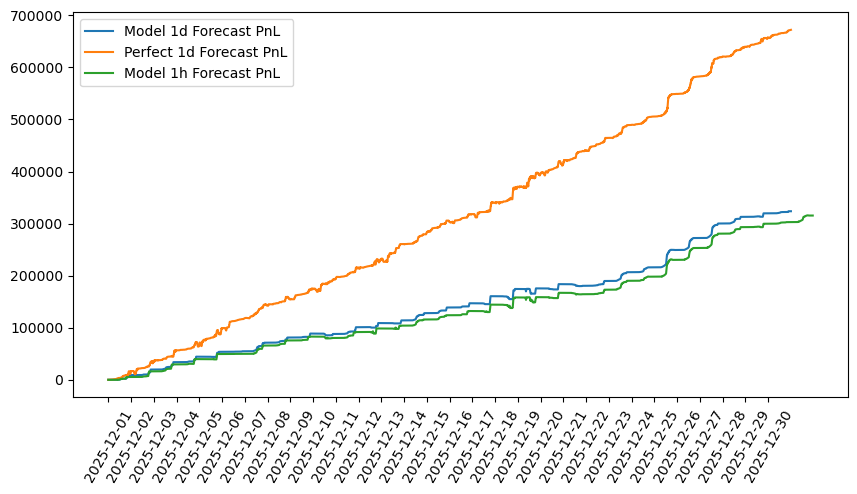

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(results_forecast["time"], results_forecast["PnL"], label="Model 1d Forecast PnL")
plt.plot(results_perfect["time"], results_perfect["PnL"], label="Perfect 1d Forecast PnL")
plt.plot(results_short["time"], results_short["PnL"], label="Model 1h Forecast PnL")
plt.xticks(results_forecast["time"][::288], rotation=60)
plt.legend()

# observe that the perfect 1d forecast clears both, unsurprisingly, but also that the model 1d forecast only
# barely beats the 1h model. 